In [1]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

print("Data Loaded ✅")

Data Loaded ✅


In [2]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(payments, on="order_id", how="left")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12


In [3]:
df.shape

(118434, 30)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   customer_unique_id             118434 non-null  object 
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  object 
 11  customer_state                 118434 non-null  object 
 12  order_item_id                 

In [5]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
product_category_name            2528
product_name_lenght              2528
product_description_lenght       2528
product_photos_qty               2528
product_weight_g                  850
product_length_cm                 850
product_height_cm                 850
product_width_cm                  850
payment_sequ

In [6]:
df= df.dropna(subset=["payment_value"])

In [7]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [8]:
df["order_purchase_timestamp"].head()

0   2017-10-02 10:56:33
1   2017-10-02 10:56:33
2   2017-10-02 10:56:33
3   2018-07-24 20:41:37
4   2018-08-08 08:38:49
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [9]:
df["month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [15]:
monthly_revenue = df.groupby("month")["payment_value"].sum()

monthly_revenue

month
2016-09        388.47
2016-10      76120.17
2016-12         19.62
2017-01     189015.66
2017-02     349701.93
2017-03     544738.23
2017-04     510891.55
2017-05     731017.09
2017-06     608891.38
2017-07     744599.53
2017-08     876129.37
2017-09    1023095.49
2017-10    1031505.53
2017-11    1599444.18
2017-12    1057582.34
2018-01    1415348.54
2018-02    1311260.71
2018-03    1480045.50
2018-04    1497843.94
2018-05    1511113.00
2018-06    1298685.81
2018-07    1359421.48
2018-08    1248837.93
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

In [18]:
import matplotlib.pyplot as plt

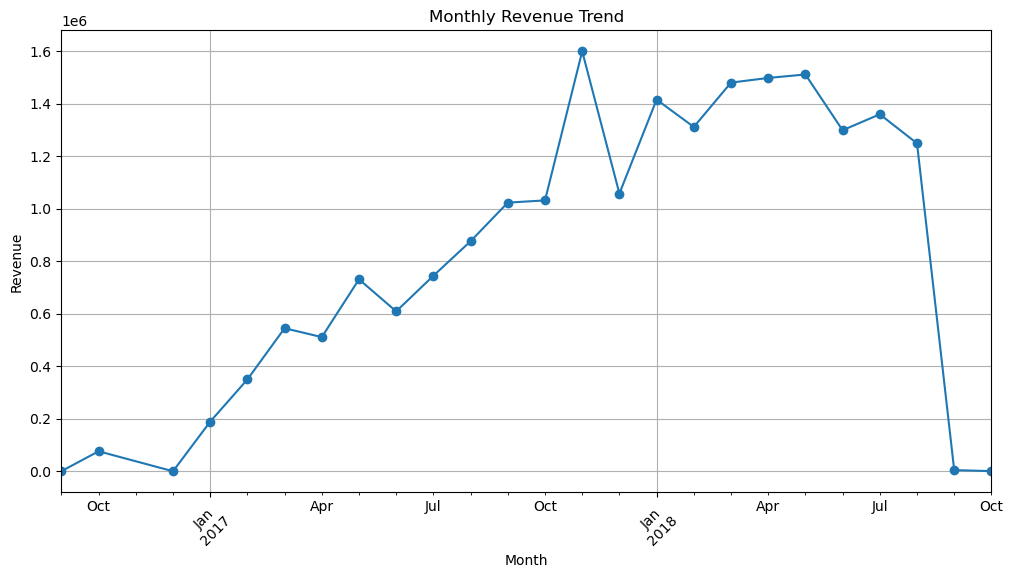

In [19]:
monthly_revenue.plot(figsize=(12,6), marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [20]:
customer_revenue = df.groupby("customer_unique_id")["payment_value"].sum().reset_index()

customer_revenue = customer_revenue.sort_values(by="payment_value", ascending=False)

customer_revenue.head()

,customer_unique_id,payment_value
3826,0a0a92112bd4c708ca5fde585afaa872,109312.64
39720,698e1cf81d01a3d389d96145f7fa6df8,45256.00
73663,c402f431464c72e27330a67f7b94d4fb,44048.00
24121,4007669dec559734d6f53e029e360987,36489.24
89999,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00


In [21]:
top_customers = customer_revenue.head(10)

top_customers

,customer_unique_id,payment_value
3826,0a0a92112bd4c708ca5fde585afaa872,109312.64
39720,698e1cf81d01a3d389d96145f7fa6df8,45256.00
73663,c402f431464c72e27330a67f7b94d4fb,44048.00
24121,4007669dec559734d6f53e029e360987,36489.24
89999,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00
44447,763c8b1c9c68a0229c42c9fc6f662b93,29099.52
75268,c8460e4251689ba205045f3ea17884a1,27935.46
88261,eae0a83d752b1dd32697e0e7b4221656,25051.89
23071,3d47f4368ccc8e1bb4c4a12dbda7111b,22346.60
65406,adfa1cab2b2c8706db21bb13c0a1beb1,19457.04


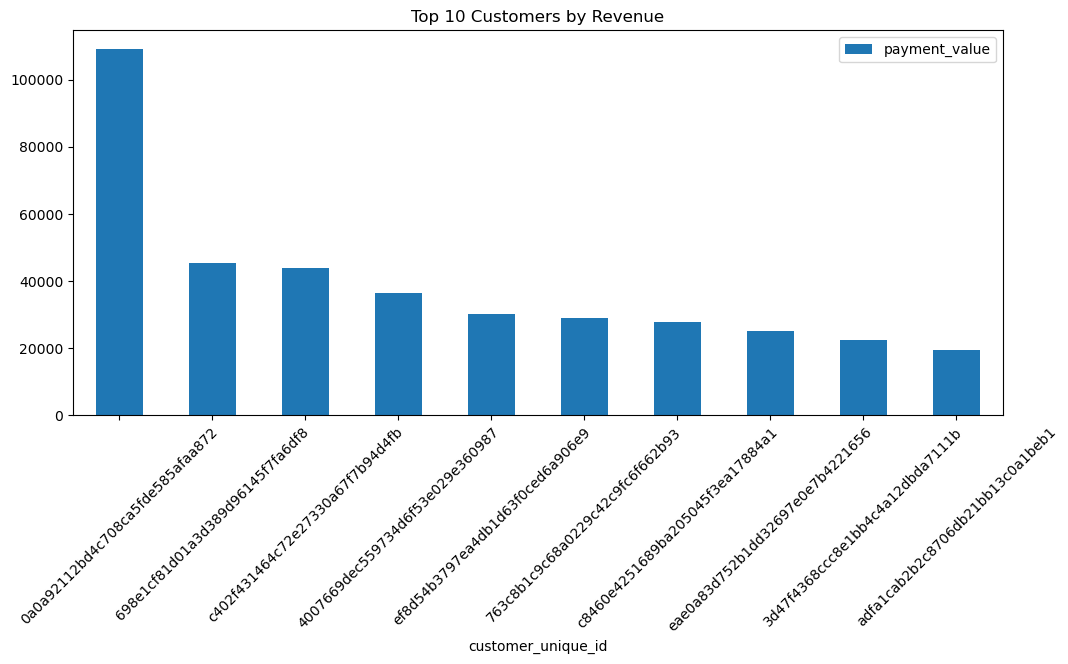

In [22]:
top_customers.plot(kind='bar', x='customer_unique_id', y='payment_value', figsize=(12,5))
plt.title("Top 10 Customers by Revenue")
plt.xticks(rotation=45)
plt.show()

In [25]:
latest_date = df["order_purchase_timestamp"].max()

rfm = df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (latest_date - x.max()).days,
    "order_id": "count",
    "payment_value": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
0000f46a3911fa3c0805444483337064,585,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [27]:
rfm["R"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_Score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

rfm.head()


,Recency,Frequency,Monetary,R,F,M,RFM_Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,3,213


In [28]:
def segment(x):
    if x == "444":
        return "Best Customers"
    elif x[0] == "4":
        return "Recent Customers"
    elif x[1] == "4":
        return "Frequent Customers"
    else:
        return "Others"

rfm["Segment"] = rfm["RFM_Score"].apply(segment)

rfm["Segment"].value_counts()

Segment
Others                54063
Recent Customers      21136
Frequent Customers    17968
Best Customers         2928
Name: count, dtype: int64

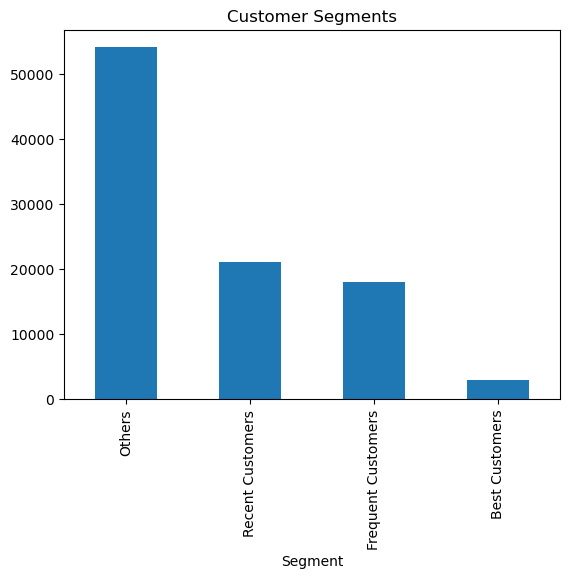

In [29]:
rfm["Segment"].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

In [31]:
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])

df["delivery_time"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days

df["delivery_time"].describe()

count    115034.000000
mean         12.018142
std           9.459134
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time, dtype: float64

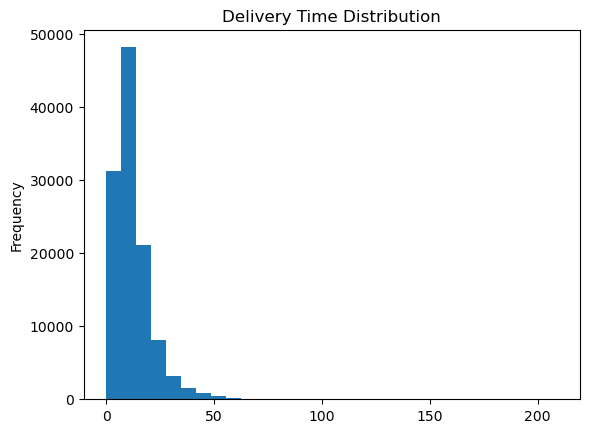

In [32]:
df["delivery_time"].plot(kind='hist', bins=30)
plt.title("Delivery Time Distribution")
plt.show()

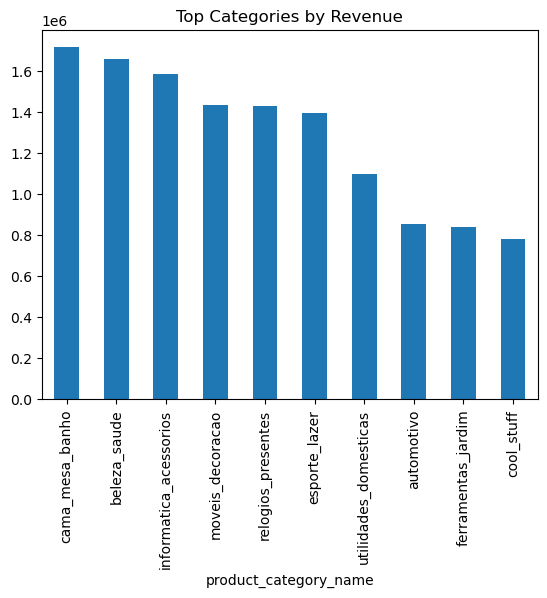

In [33]:
top_cat = df.groupby("product_category_name")["payment_value"].sum().sort_values(ascending=False).head(10)

top_cat.plot(kind='bar')
plt.title("Top Categories by Revenue")
plt.show()

# -- what We Get From That Project 
Advanced Insights:

- Revenue concentration suggests dependency on few customer segments  
- High number of low-value customers indicates poor retention funnel  
- Seasonal spikes suggest opportunity for targeted campaigns  
- Delivery delays may impact repeat purchase behavior  

Business Recommendations:

- Implement loyalty programs for frequent customers  
- Retarget recent customers to increase frequency  
- Optimize logistics to reduce delivery time  
- Focus marketing on top-performing categories